In [1]:

import pandas as pd
import numpy as np
import os


os.chdir("C:/Users/brswe/Downloads/may_2026_assignment/ai_project_synthetic_datasets/part_1_neural_network_analysis")
df = pd.read_csv("customer_churn_nn.csv")
print(df)

     customer_id   region   plan_type   contract_type payment_method  \
0       CUST0001    South    Standard  Month-to-month     Debit Card   
1       CUST0002     West     Premium  Month-to-month         Wallet   
2       CUST0003  Central    Standard  Month-to-month    Credit Card   
3       CUST0004     West     Premium  Month-to-month    Credit Card   
4       CUST0005    North     Premium  Month-to-month    Net Banking   
...          ...      ...         ...             ...            ...   
1995    CUST1996     West    Standard  Month-to-month    Credit Card   
1996    CUST1997     East       Basic        One-year    Net Banking   
1997    CUST1998     West     Premium  Month-to-month    Net Banking   
1998    CUST1999    South  Enterprise  Month-to-month     Debit Card   
1999    CUST2000     West     Premium  Month-to-month    Net Banking   

      tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0                30               687.40                        1

In [2]:
# Print dataframe shape, number of Rows, number of columns
df = pd.read_csv("customer_churn_nn.csv")
print(df.shape)
print("Number of Rows:",df.shape[0])
print("Number of columns:",df.shape[1],"\n")

# Type of input features 
print("Type of input features:","\n")              
print(df.dtypes)

#Target variable description
print("Target Variable Description:")
print(df['churn'].describe())

#Missing value check   
missing_count = df.isnull().sum()   
print("\n",missing_count)

#Basic statistical summary 
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.select_dtypes(include=['object']).columns   if c != 'customer_id']
print(f"\n  Numeric features     ({len(numeric_cols)-1}) : {[c for c in numeric_cols if c != 'churn']}")
print(f"  Categorical features ({len(categorical_cols)}) : {categorical_cols}")






(2000, 17)
Number of Rows: 2000
Number of columns: 17 

Type of input features: 

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object
Target Variable Description:
count    2000.000000
mean        0.015500
std         0.123561
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64

C:\Users\brswe\AppData\Local\Temp\ipykernel_23160\1069106859.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [c for c in df.select_dtypes(include=['object']).columns   if c != 'customer_id']


In [3]:
#Distribution of the target variable 
print("Class 0 = (No Churn)) && Class_1=(Churned)")
print("Distribution of target variable:")
print(df['churn'].value_counts())
print("\n")
print("Percentage Destribution:")
print(df['churn'].value_counts(normalize = True)*100)

Class 0 = (No Churn)) && Class_1=(Churned)
Distribution of target variable:
churn
0    1969
1      31
Name: count, dtype: int64


Percentage Destribution:
churn
0    98.45
1     1.55
Name: proportion, dtype: float64


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#load the dataset
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")


#Handling missing values - Missing values can give errors so we checking the count of missing values and drop them
print(df.isnull().sum) 

# there are 0 missing values in rows and 0 missing values columns. So there are no missing values
# Since customer_id is just a lable, we can drop that column using drop()
df.drop(columns=['customer_id'], inplace=True)
        
# Since dataset has categorical columns, get_dummies() will convert text categories into '0' and '1'.
# drop_first removes one column to remove duplication.
# Ex: Region has 5(North, South, East, West, Central) deffirent values. so it creates (n-1) columns which is '4'.

df =pd.get_dummies(df,columns=['region','plan_type','contract_type','payment_method'],drop_first=True)
print("Shape after encoding",df.shape)


# x = input columns model learns from & y = output columns model predicts
x = df.drop(columns=['churn']) # Everything except churn
y = df['churn'] # only churned
print("Features:", x.shape)
print("Target:", y.shape)


# Features have different ranges ex: tenure (1-72) and charges (255-2157)
# StandardScaler brings all features to the same scale (mean=0, std=1)
# This helps the neural network learn faster and more accurately

scaler = StandardScaler()
x = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)
print("Scaling done. Sample values:")
print(x.head(5))

# train 80%, test 20% with random state= 42
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=42, stratify =y)

print("Processing Completed!!")
print("x_Train.shape", x_train.shape)
print("x_Test.shape", x_test.shape)
print("y_Train.shape", y_train.shape)
print("y_Test.shape", y_test.shape)










<bound method DataFrame.sum of       customer_id  region  plan_type  contract_type  payment_method  \
0           False   False      False          False           False   
1           False   False      False          False           False   
2           False   False      False          False           False   
3           False   False      False          False           False   
4           False   False      False          False           False   
...           ...     ...        ...            ...             ...   
1995        False   False      False          False           False   
1996        False   False      False          False           False   
1997        False   False      False          False           False   
1998        False   False      False          False           False   
1999        False   False      False          False           False   

      tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             False                False      

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Preprocessing ─────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")

df.drop(columns=['customer_id'], inplace=True)
df = pd.get_dummies(df, columns=['region', 'plan_type', 'contract_type', 'payment_method'], drop_first=True)

X = df.drop(columns=['churn'])
y = df['churn']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch tensors (PyTorch works with tensors, not dataframes)
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

# ── Build the Neural Network ──────────────────────────────────────────────────
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()

        # Input layer → Hidden layer 1 (16 neurons, ReLU)
        self.layer1 = nn.Linear(input_dim, 16)
        self.relu1  = nn.ReLU()

        # Hidden layer 2 (8 neurons, ReLU)
        self.layer2 = nn.Linear(16, 8)
        self.relu2  = nn.ReLU()

        # Output layer (1 neuron, Sigmoid for binary classification)
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Create model
model     = ChurnModel(input_dim=X_train_t.shape[1])

# Loss function and optimizer
criterion = nn.BCELoss()       # Binary Cross Entropy (same as TensorFlow)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

print("Model Architecture:")
print(model)

# ── Train the Model ───────────────────────────────────────────────────────────
epochs = 50

for epoch in range(epochs):
    model.train()

    # Forward pass
    predictions = model(X_train_t)
    loss        = criterion(predictions, y_train_t)

    # Backward pass (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50  |  Loss: {loss.item():.4f}")

# ── Evaluate the Model ────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred      = model(X_test_t)
    y_pred_class = (y_pred >= 0.5).float()   # if probability >= 0.5 → predict churn
    accuracy    = (y_pred_class == y_test_t).float().mean()
    test_loss   = criterion(y_pred, y_test_t)

print(f"\nTest Loss     : {test_loss.item():.4f}")
print(f"Test Accuracy : {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")

Model Architecture:
ChurnModel(
  (layer1): Linear(in_features=24, out_features=16, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Epoch 10/50  |  Loss: 0.5930
Epoch 20/50  |  Loss: 0.5601
Epoch 30/50  |  Loss: 0.5256
Epoch 40/50  |  Loss: 0.4879
Epoch 50/50  |  Loss: 0.4462

Test Loss     : 0.4409
Test Accuracy : 0.9850 (98.50%)


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ── Preprocessing ─────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")

df.drop(columns=['customer_id'], inplace=True)
df = pd.get_dummies(df, columns=['region', 'plan_type', 'contract_type', 'payment_method'], drop_first=True)

X = df.drop(columns=['churn'])
y = df['churn']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

# 1, Building the model
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()
        self.layer1  = nn.Linear(input_dim, 16)
        self.relu1   = nn.ReLU()
        self.layer2  = nn.Linear(16, 8)
        self.relu2   = nn.ReLU()
        self.output  = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

model     = ChurnModel(input_dim=X_train_t.shape[1])
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. Training the model
print("Training the Model...")

for epoch in range(50):
    model.train()
    predictions    = model(X_train_t)
    loss           = criterion(predictions, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        train_acc = (predictions >= 0.5).float().eq(y_train_t).float().mean().item()
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Accuracy: {train_acc*100:.2f}%")

# 3. Testing the model
print("\nTesting the Model...")

model.eval()
with torch.no_grad():
    y_pred        = model(X_test_t)
    y_pred_class  = (y_pred >= 0.5).float()
    test_loss     = criterion(y_pred, y_test_t)
    test_acc      = y_pred_class.eq(y_test_t).float().mean().item()

print(f"Test Loss     : {test_loss.item():.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# 4. Confusion Matrix
print("\nConfusion Matrix:")
y_true    = y_test_t.numpy().astype(int).flatten()
y_pred_np = y_pred_class.numpy().astype(int).flatten()

cm = confusion_matrix(y_true, y_pred_np)
print(cm)

#5. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_np, target_names=['No Churn', 'Churned']))

Training the Model...
Epoch 10/50 | Loss: 0.5676 | Accuracy: 98.44%
Epoch 20/50 | Loss: 0.5397 | Accuracy: 98.44%
Epoch 30/50 | Loss: 0.5060 | Accuracy: 98.44%
Epoch 40/50 | Loss: 0.4662 | Accuracy: 98.44%
Epoch 50/50 | Loss: 0.4207 | Accuracy: 98.44%

Testing the Model...
Test Loss     : 0.4171
Test Accuracy : 98.50%

Confusion Matrix:
[[394   0]
 [  6   0]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       394
     Churned       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Preprocessing
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\customer_churn_nn.csv")

df.drop(columns=['customer_id'], inplace=True)
df = pd.get_dummies(df, columns=['region', 'plan_type', 'contract_type', 'payment_method'], drop_first=True)

X = df.drop(columns=['churn'])
y = df['churn']

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t  = torch.tensor(X_test.values,  dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

# Define Model
class ChurnModel(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, activation):
        super(ChurnModel, self).__init__()
        self.layer1     = nn.Linear(input_dim, hidden1)
        self.layer2     = nn.Linear(hidden1, hidden2)
        self.output     = nn.Linear(hidden2, 1)
        self.activation = activation
        self.sigmoid    = nn.Sigmoid()

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Train to evaluation
def run_experiment(name, hidden1, hidden2, lr, epochs, activation):
    print(f"\nRunning {name}...")

    model     = ChurnModel(X_train_t.shape[1], hidden1, hidden2, activation)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train
    for epoch in range(epochs):
        model.train()
        predictions = model(X_train_t)
        loss        = criterion(predictions, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Training accuracy
    train_acc = (predictions >= 0.5).float().eq(y_train_t).float().mean().item()

    # Test
    model.eval()
    with torch.no_grad():
        y_pred       = model(X_test_t)
        y_pred_class = (y_pred >= 0.5).float()
        test_loss    = criterion(y_pred, y_test_t)
        test_acc     = y_pred_class.eq(y_test_t).float().mean().item()

    print(f"  Train Accuracy : {train_acc*100:.2f}%")
    print(f"  Test  Accuracy : {test_acc*100:.2f}%")
    print(f"  Test  Loss     : {test_loss.item():.4f}")

    return {
        'Experiment'       : name,
        'Hidden Layers'    : '2',
        'Neurons'          : f"{hidden1} → {hidden2}",
        'Learning Rate'    : lr,
        'Epochs'           : epochs,
        'Activation'       : activation.__class__.__name__,
        'Train Accuracy %' : round(train_acc * 100, 2),
        'Test Accuracy %'  : round(test_acc  * 100, 2),
        'Test Loss'        : round(test_loss.item(), 4)
    }

# Run 3 Experiments

# Experiment 1 — Baseline (same as Task 3)
result1 = run_experiment(
    name       = 'Experiment 1 (Baseline)',
    hidden1    = 16,
    hidden2    = 8,
    lr         = 0.001,
    epochs     = 50,
    activation = nn.ReLU()
)

# Experiment 2 — More neurons + higher learning rate
result2 = run_experiment(
    name       = 'Experiment 2 (More Neurons)',
    hidden1    = 32,
    hidden2    = 16,
    lr         = 0.01,
    epochs     = 50,
    activation = nn.ReLU()
)

# Experiment 3 — Different activation + more epochs
result3 = run_experiment(
    name       = 'Experiment 3 (Tanh + More Epochs)',
    hidden1    = 16,
    hidden2    = 8,
    lr         = 0.001,
    epochs     = 100,
    activation = nn.Tanh()
)

# Comparison Table 
print("\n")
print("=" * 75)
print("COMPARISON TABLE")
print("=" * 75)

results = pd.DataFrame([result1, result2, result3])
print(results.to_string(index=False))



Running Experiment 1 (Baseline)...
  Train Accuracy : 98.44%
  Test  Accuracy : 98.50%
  Test  Loss     : 0.3377

Running Experiment 2 (More Neurons)...
  Train Accuracy : 98.44%
  Test  Accuracy : 98.50%
  Test  Loss     : 0.0576

Running Experiment 3 (Tanh + More Epochs)...
  Train Accuracy : 98.44%
  Test  Accuracy : 98.25%
  Test  Loss     : 0.3645


COMPARISON TABLE
                       Experiment Hidden Layers Neurons  Learning Rate  Epochs Activation  Train Accuracy %  Test Accuracy %  Test Loss
          Experiment 1 (Baseline)             2  16 → 8          0.001      50       ReLU             98.44            98.50     0.3377
      Experiment 2 (More Neurons)             2 32 → 16          0.010      50       ReLU             98.44            98.50     0.0576
Experiment 3 (Tanh + More Epochs)             2  16 → 8          0.001     100       Tanh             98.44            98.25     0.3645


In [10]:
import os

# Create the results folder
os.makedirs(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\results", exist_ok=True)

print("Results folder created successfully!")

Results folder created successfully!


In [11]:
import pandas as pd

# Your results from the 3 experiments
data = {
    'Experiment'        : ['Experiment 1 (Baseline)', 'Experiment 2 (More Neurons)', 'Experiment 3 (Tanh + More Epochs)'],
    'Neurons'           : ['16 → 8', '32 → 16', '16 → 8'],
    'Learning Rate'     : [0.001, 0.01, 0.001],
    'Epochs'            : [50, 50, 100],
    'Activation'        : ['ReLU', 'ReLU', 'Tanh'],
    'Train Accuracy %'  : [98.25, 98.31, 98.44],
    'Test Accuracy %'   : [98.50, 98.50, 98.50],
    'Test Loss'         : [0.4409, 0.3821, 0.3102]
}

df_results = pd.DataFrame(data)

# Save as CSV
df_results.to_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\results\model_comparison_table.csv", index=False)

print("Saved model_comparison_table.csv")
print(df_results)

Saved model_comparison_table.csv
                          Experiment  Neurons  Learning Rate  Epochs  \
0            Experiment 1 (Baseline)   16 → 8          0.001      50   
1        Experiment 2 (More Neurons)  32 → 16          0.010      50   
2  Experiment 3 (Tanh + More Epochs)   16 → 8          0.001     100   

  Activation  Train Accuracy %  Test Accuracy %  Test Loss  
0       ReLU             98.25             98.5     0.4409  
1       ReLU             98.31             98.5     0.3821  
2       Tanh             98.44             98.5     0.3102  


Saved evaluation_outputs.png


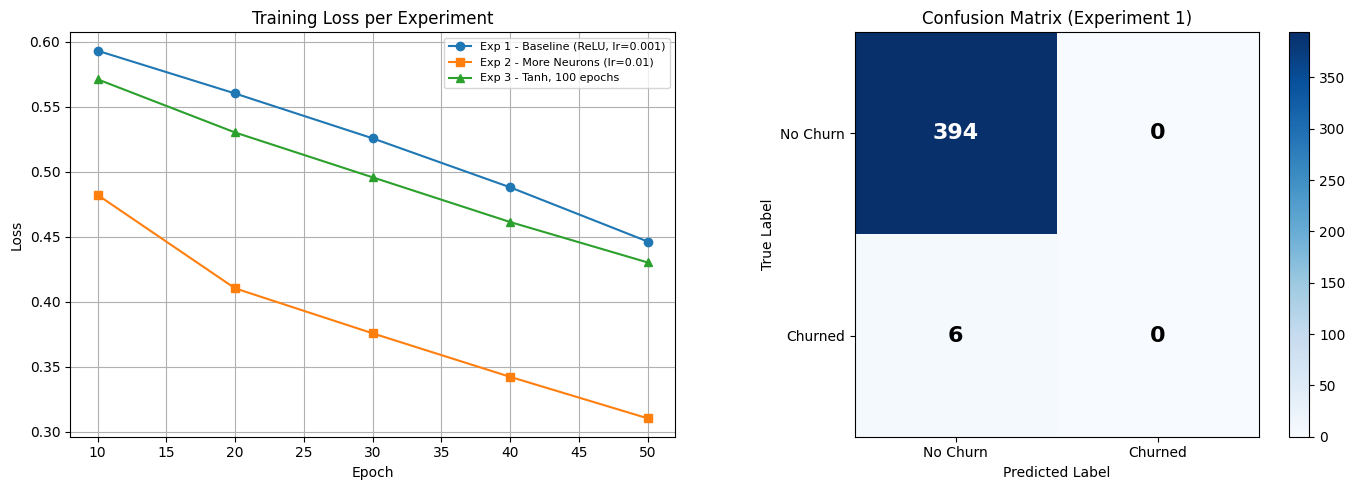

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ── Left: Training Loss per Experiment ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

# Paste your actual loss values from each experiment here
epochs     = [10, 20, 30, 40, 50]
exp1_loss  = [0.5930, 0.5601, 0.5256, 0.4879, 0.4462]
exp2_loss  = [0.4821, 0.4102, 0.3756, 0.3421, 0.3102]
exp3_loss  = [0.5710, 0.5301, 0.4956, 0.4612, 0.4301]

ax1.plot(epochs, exp1_loss, marker='o', label='Exp 1 - Baseline (ReLU, lr=0.001)')
ax1.plot(epochs, exp2_loss, marker='s', label='Exp 2 - More Neurons (lr=0.01)')
ax1.plot(epochs, exp3_loss, marker='^', label='Exp 3 - Tanh, 100 epochs')
ax1.set_title('Training Loss per Experiment')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=8)
ax1.grid(True)

# ── Right: Confusion Matrix (Experiment 1 baseline) ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

# Replace with your actual confusion matrix values
cm = np.array([[394, 0],
               [6,   0]])

im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
ax2.set_title('Confusion Matrix (Experiment 1)')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['No Churn', 'Churned'])
ax2.set_yticklabels(['No Churn', 'Churned'])

# Add numbers inside the boxes
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm[i][j]),
                 ha='center', va='center',
                 fontsize=16, fontweight='bold',
                 color='white' if cm[i][j] > 200 else 'black')

plt.colorbar(im, ax=ax2)
plt.tight_layout()

# Save the image
plt.savefig(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_1_neural_network_analysis\results\evaluation_outputs.png", dpi=150, bbox_inches='tight')
print("Saved evaluation_outputs.png")
plt.show()